In [108]:
import numpy as np
import pandas as pd
from plotly.io import show
from matplotlib import pyplot as plt
import mplfinance as mpf
import seaborn as sns
from tabulate import tabulate
import vectorbt as vbt

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Backtest import Backtest
from ggTrader.Signals import Signals


Setup

In [109]:
# setup
k = KrakenHistoricalData()

start_equity = 1000
symbols = ["BTC"]
interval = "4h"
n_trials = 1000
sampler = RandomSampler(seed=42)  # optional seed for reproducibility
# sampler = TPESampler(seed=42)

# Time Range
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 6)
start = pd.to_datetime("2023-01-01").tz_localize('UTC')

# Indicator Params
params = {'sar_acceleration': 0.02,
          'sar_maximum': 0.2,
          'atr_multiplier': 3,
          'adx_threshold': 25,
          'adx_length': 14,
          'ce_high_length': 22,
          'ce_low_length': 22,
          'atr_length': 14,  # atr multiplier for chandelier exit
          }

# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
# df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)
df_multi = k.get_ohlcv_df(symbols, interval=interval)

# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]

#benchmark, buy and hold
df_bench_mark = pd.DataFrame()
df_bench_mark['close'] = df['close'].copy()
df_bench_mark['equity'] = start_equity * df_bench_mark['close'] / (df_bench_mark['close'].iloc[0])
print(df_bench_mark.tail(10))


                                   close       equity
2025-09-28 12:00:00+00:00  110011.101562  6659.549805
2025-09-28 16:00:00+00:00  110353.203125  6680.258301
2025-09-28 20:00:00+00:00  112127.796875  6787.684570
2025-09-29 00:00:00+00:00  111862.500000  6771.624023
2025-09-29 04:00:00+00:00  111863.601562  6771.690918
2025-09-29 08:00:00+00:00  112093.398438  6785.602051
2025-09-29 12:00:00+00:00  113844.000000  6891.575195
2025-09-29 16:00:00+00:00  114358.296875  6922.708008
2025-09-29 20:00:00+00:00  114365.203125  6923.125977
2025-09-30 00:00:00+00:00  114430.601562  6927.084961


#Optuna setup

In [110]:
import math


def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", -10, 90, step=2)  #
    params['adx_length'] = trial.suggest_int("adx_length", 2, 200,step=2)
    params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.01, 1, step=0.01)
    params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.05, 1, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 8, step=0.1)
    params['atr_length'] = trial.suggest_int("atr_length", 2, 200, step=2)
    params['ce_low_length'] = trial.suggest_int("ce_low_length", 2, 200, step=2)
    params['ce_high_length'] = trial.suggest_int("ce_high_length", 2, 200, step=2)

    s = Signals(**params)

    signals = s.calc_signals(df.copy())
    close = signals['close']
    entries = signals['entry_signal']
    exits = signals['exit_signal']
    # Build target allocation:
    # 1.0 = 100% of portfolio in asset
    # 0.0 = 100% in cash
    size = pd.Series(np.nan, index=close.index)
    size[entries] = 1.0   # on buy signal: go all-in
    size[exits] = 0.0     # on sell signal: go flat

    pf = vbt.Portfolio.from_orders(
        close=close,
        size=size,
        size_type='targetpercent',  # interpret `size` as target weight
        direction='longonly',
        init_cash=start_equity,           # starting cash
        fees=transaction_fee,                 # 0.1% fee (optional)
        slippage=0.0005,            # optional
    )
    stats = pf.stats()
    sharpe = stats['Sharpe Ratio']
    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    return sharpe


study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=n_trials)

[I 2025-11-07 21:44:09,921] A new study created in memory with name: no-name-271efafd-0894-4314-a750-cf95e7edc91e
[I 2025-11-07 21:44:10,198] Trial 0 pruned. Invalid objective (NaN/Inf).
[I 2025-11-07 21:44:10,467] Trial 1 pruned. Invalid objective (NaN/Inf).
[I 2025-11-07 21:44:10,712] Trial 2 finished with value: 0.2465780085407661 and parameters: {'adx_threshold': 20, 'adx_length': 106, 'sar_acceleration': 0.44, 'sar_maximum': 0.32, 'atr_multiplier': 5.3, 'atr_length': 28, 'ce_low_length': 60, 'ce_high_length': 74}. Best is trial 2 with value: 0.2465780085407661.
[I 2025-11-07 21:44:10,954] Trial 3 pruned. Invalid objective (NaN/Inf).
[I 2025-11-07 21:44:11,193] Trial 4 finished with value: 0.8016303626702314 and parameters: {'adx_threshold': -4, 'adx_length': 190, 'sar_acceleration': 0.97, 'sar_maximum': 0.8200000000000001, 'atr_multiplier': 3.1, 'atr_length': 20, 'ce_low_length': 138, 'ce_high_length': 90}. Best is trial 4 with value: 0.8016303626702314.
[I 2025-11-07 21:44:11,447

Study Results

In [111]:
trials = study.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start', 'datetime_complete', 'duration', 'state'], axis=1, inplace=True)
print(tabulate(trials, headers='keys', tablefmt='github', showindex=False))


|   number |        value |   adx_length |   adx_threshold |   atr_length |   atr_multiplier |   ce_high_length |   ce_low_length |   sar_acceleration |   sar_maximum |
|----------|--------------|--------------|-----------------|--------------|------------------|------------------|-----------------|--------------------|---------------|
|      994 |   1.73942    |           12 |              50 |          168 |              5.7 |                8 |              32 |               0.9  |          0.55 |
|      291 |   1.72647    |           12 |              54 |          138 |              5.2 |               78 |              24 |               0.26 |          0.1  |
|      280 |   1.70891    |            8 |              70 |          106 |              7   |              168 |              14 |               0.59 |          1    |
|      189 |   1.70419    |            4 |              86 |          180 |              5.5 |              186 |              50 |               0.2  |   

In [112]:
best_params = study.best_params
best_value = study.best_value
print(f"\nBest --> Sharpe: {best_value:.2f} ")
print(tabulate(best_params.items(), tablefmt="github"))


Best --> Sharpe: 1.74 
|------------------|--------|
| adx_threshold    |  50    |
| adx_length       |  12    |
| sar_acceleration |   0.9  |
| sar_maximum      |   0.55 |
| atr_multiplier   |   5.7  |
| atr_length       | 168    |
| ce_low_length    |  32    |
| ce_high_length   |   8    |


Visualization

In [113]:
fig = optuna.visualization.plot_param_importances(study)
show(fig)

fig2 = optuna.visualization.plot_slice(study, params=best_params.keys())
show(fig2)


From the slice plot can notice a few things...

- ATR multiplier <2 also looks ideal as under 2 sortino values reach > 6
- ADX_length is good when < 10, I think best to cheap default of 14
- ADX_threshold looks like once it's under 20, there's not much correlation.
- ATR_length has little correlation so will keep at default of 14
- ce_high_length, keep the default value of 22
- ce_low_length the highest sortino values are achieved when ce_low_length is low, under 10
- sar_maximum is okay, keep the default of 0.2
- sar_acceleration is okay, keep the default of 0.02


Generally there aren't major correlations, but can generally see where there might be better results.  The slice plot does slightly agree with the most hyperparameter importance, since these are the only values that so some sort of correlation to sortino ratio.


NOTE:  Removed atr_length and ce_high_length from the slice plot, since they have very little correlation to sortino ratio.


In [114]:
fig3 = optuna.visualization.plot_optimization_history(study)
show(fig3)

Seaborn plots

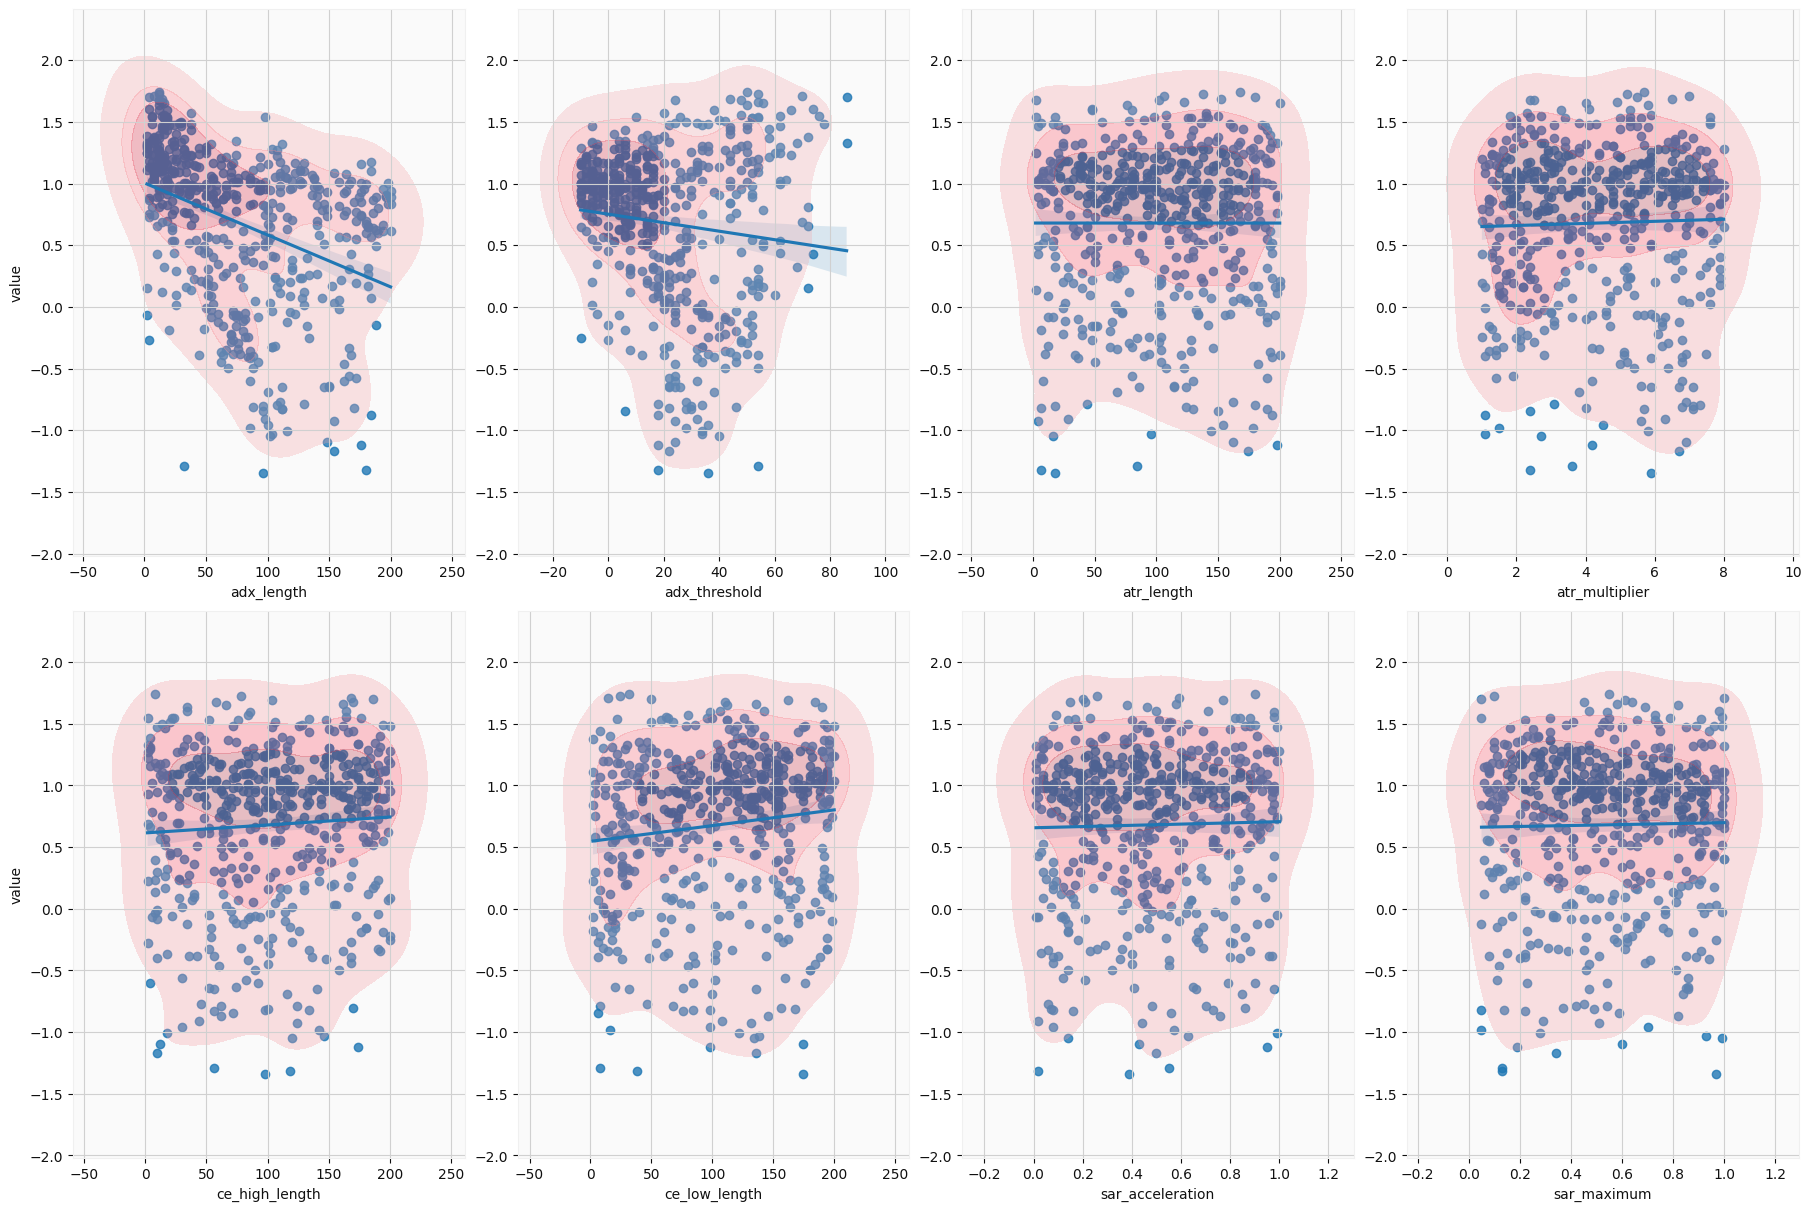

In [115]:
x_all = list(trials.columns[2:])
y_col = trials.columns[1]

fig, axes = plt.subplots(2, 4, figsize=(18, 12), constrained_layout=True)
for i, col in enumerate(x_all[:8]):  # first 8 columns
    ax = axes[i // 4, i % 4]
    sns.regplot(data=trials, x=col, y=y_col, ax=ax)
    sns.kdeplot(data=trials, x=col, y=y_col, levels=4, fill=True, color='crimson', alpha=0.3, ax=ax)
    ax.set_xlabel(col)
    if i % 4 != 0:
        ax.set_ylabel("")
plt.show()

Best Trial Backtest